# Student Depression Dataset - Preprocessing and ANN Model

In this notebook, I prepare the data for a neural network model and build a first simple ANN model using TensorFlow/Keras.

The main steps are:

1. Load the dataset
2. Handle missing values
3. Separate features and target
4. Encode categorical variables
5. Scale numerical variables
6. Split data into train and test sets
7. Build a simple ANN model
8. Train and evaluate the model

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully!
TensorFlow version: 2.21.0


In [3]:
possible_paths = [
    Path("../../data/raw/Student Depression Dataset.csv"),
    Path("../../data/Student Depression Dataset.csv"),
    Path("../data/raw/Student Depression Dataset.csv"),
    Path("../data/Student Depression Dataset.csv"),
    Path("Student Depression Dataset.csv"),
]

csv_path = None

for path in possible_paths:
    if path.exists():
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError(
        "CSV file not found. Please check where 'Student Depression Dataset.csv' is saved."
    )

df = pd.read_csv(csv_path)

print(f"Dataset loaded from: {csv_path}")
print(f"Shape: {df.shape}")

df.head()

Dataset loaded from: ..\..\data\Student Depression Dataset.csv
Shape: (27901, 18)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [5]:
df.isnull().sum().sort_values(ascending=False).head(10)

Financial Stress                         3
id                                       0
Gender                                   0
Family History of Mental Illness         0
Work/Study Hours                         0
Have you ever had suicidal thoughts ?    0
Degree                                   0
Dietary Habits                           0
Sleep Duration                           0
Job Satisfaction                         0
dtype: int64

In [6]:
df_model = df.copy()

df_model = df_model.drop(columns=["id"])

df_model.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [7]:
target_col = "Depression"

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (27901, 16)
y shape: (27901,)


In [8]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']

Categorical features:
['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (22320, 16)
X_test: (5581, 16)
y_train distribution:
Depression
1    0.585
0    0.415
Name: proportion, dtype: float64

y_test distribution:
Depression
1    0.586
0    0.414
Name: proportion, dtype: float64


In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [11]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (22320, 111)
Processed X_test shape: (5581, 111)


In [12]:
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

print(type(X_train_processed))
print(X_train_processed.shape)

<class 'numpy.ndarray'>
(22320, 111)


In [13]:
input_dim = X_train_processed.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,129 (16.13 KB)

 Trainable params: 4,129 (16.13 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
558/558 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8272 - loss: 0.3958 - val_accuracy: 0.8389 - val_loss: 0.3642
Epoch 2/30
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 983us/step - accuracy: 0.8500 - loss: 0.3476 - val_accuracy: 0.8409 - val_loss: 0.3639
Epoch 3/30
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8514 - loss: 0.3446 - val_accuracy: 0.8396 - val_loss: 0.3613
Epoch 4/30
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8513 - loss: 0.3424 - val_accuracy: 0.8416 - val_loss: 0.3619
Epoch 5/30
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8514 - loss: 0.3409 - val_accuracy: 0.8398 - val_loss: 0.3612
Epoch 6/30
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8543 - loss: 0.3381 - val_accuracy: 0.8418 - val_loss: 0.3624
Epoch 7/30
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8547 - loss: 0.3363 - val_accuracy: 0.8394 - val_loss: 0.3643
Epoch 8/30
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8558 - loss: 0.3343 - val_accuracy: 

In [15]:
history_df = pd.DataFrame(history.history)

history_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.827229,0.395759,0.838934,0.364194
1,0.849966,0.347565,0.840950,0.363949
2,0.851422,0.344645,0.839606,0.361275
3,0.851254,0.342420,0.841622,0.361894
4,0.851366,0.340941,0.839830,0.361183


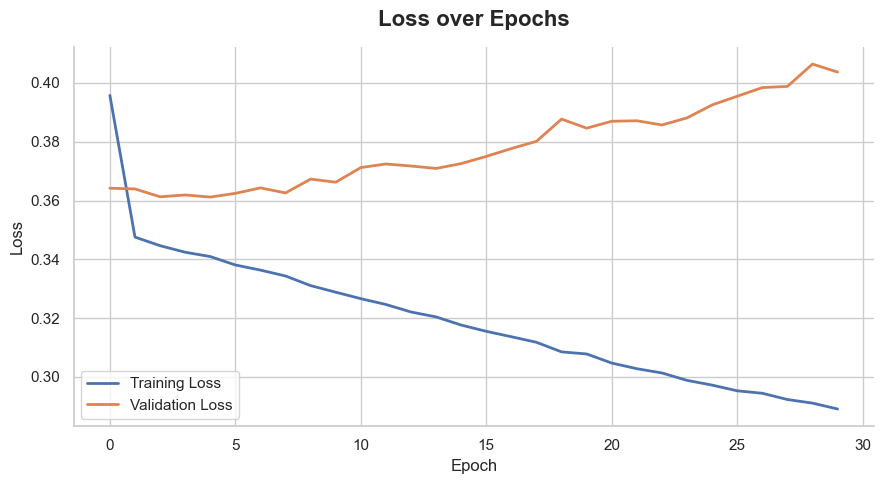

In [16]:
plt.figure(figsize=(9, 5))

plt.plot(history_df["loss"], label="Training Loss", linewidth=2)
plt.plot(history_df["val_loss"], label="Validation Loss", linewidth=2)

plt.title("Loss over Epochs", weight="bold", pad=15)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

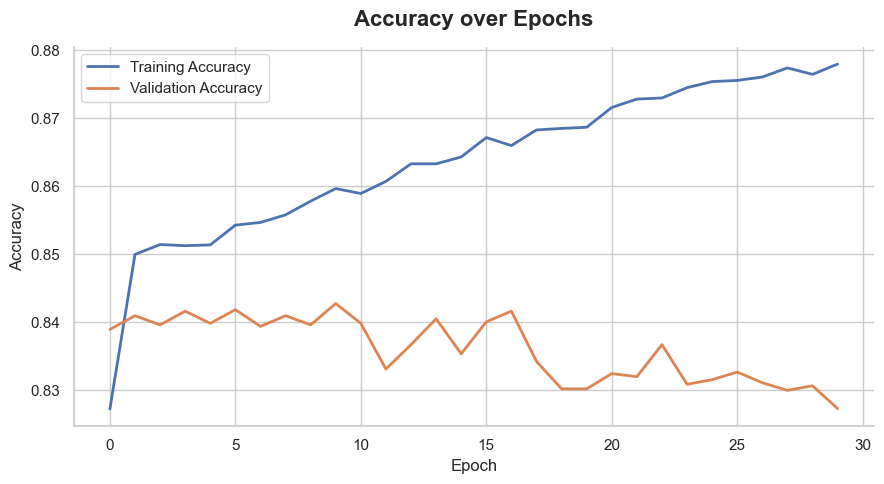

In [17]:
plt.figure(figsize=(9, 5))

plt.plot(history_df["accuracy"], label="Training Accuracy", linewidth=2)
plt.plot(history_df["val_accuracy"], label="Validation Accuracy", linewidth=2)

plt.title("Accuracy over Epochs", weight="bold", pad=15)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [18]:
y_pred_proba = model.predict(X_test_processed).ravel()

y_pred = (y_pred_proba >= 0.5).astype(int)

print("First 10 predicted probabilities:")
print(y_pred_proba[:10])

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step
First 10 predicted probabilities:
[9.8738557e-01 5.1186359e-01 9.0003991e-01 1.3125038e-01 3.7842342e-01
 1.9562367e-01 4.0000162e-01 9.6739531e-01 4.5213866e-04 9.9491131e-01]

First 10 predicted classes:
[1 1 1 0 0 0 0 1 0 1]


In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Average Precision"],
    "Score": [accuracy, precision, recall, f1, roc_auc, avg_precision]
})

results

,Metric,Score
0,Accuracy,0.829242
1,Precision,0.845626
2,Recall,0.866585
3,F1-score,0.855977
4,ROC-AUC,0.904164
5,Average Precision,0.922671


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79      2313
           1       0.85      0.87      0.86      3268

    accuracy                           0.83      5581
   macro avg       0.83      0.82      0.82      5581
weighted avg       0.83      0.83      0.83      5581



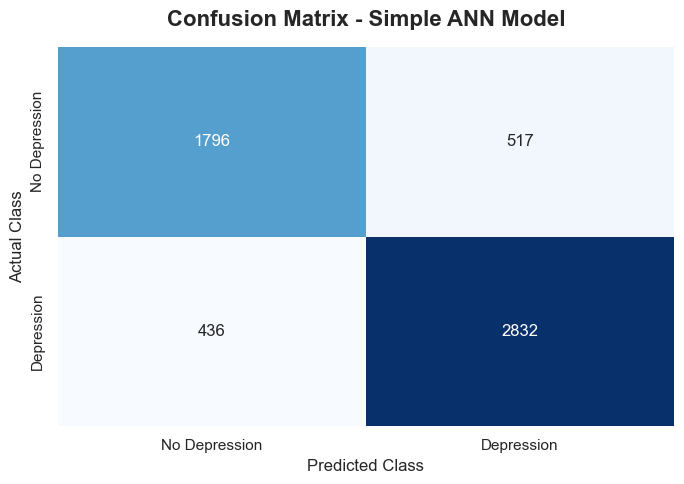

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Depression", "Depression"],
    yticklabels=["No Depression", "Depression"]
)

plt.title("Confusion Matrix - Simple ANN Model", weight="bold", pad=15)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

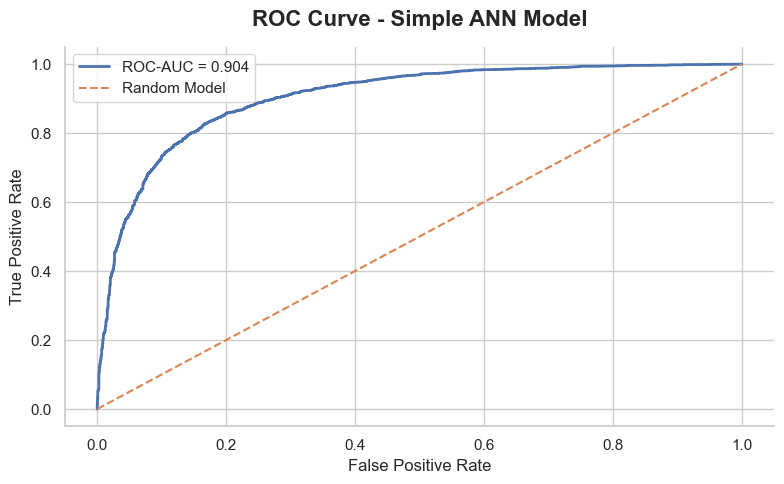

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 5))

plt.plot(fpr, tpr, linewidth=2, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random Model")

plt.title("ROC Curve - Simple ANN Model", weight="bold", pad=15)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

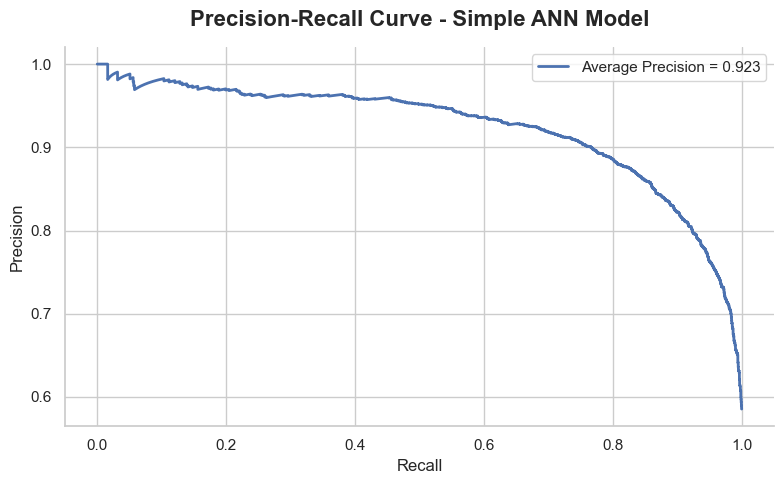

In [23]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 5))

plt.plot(recall_curve, precision_curve, linewidth=2, label=f"Average Precision = {avg_precision:.3f}")

plt.title("Precision-Recall Curve - Simple ANN Model", weight="bold", pad=15)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

## Training Interpretation

The simple ANN model learns quickly during the first epochs. The training loss decreases and the training accuracy increases over time.

However, the validation loss starts to increase while the training loss continues to decrease. This indicates mild overfitting. The model becomes better on the training data, but it does not continue to improve on unseen validation data.

To improve the model, the next step is to use techniques such as EarlyStopping, Dropout, L2 regularization and hyperparameter tuning.

## Simple ANN Model Interpretation

The simple ANN model performs well as a baseline model. It reaches an accuracy of around 83%, with a recall of around 87% for the depression class.

The ROC-AUC score is around 0.90, which shows that the model has a strong ability to separate students with and without depression.

The confusion matrix shows that the model correctly identifies many students in both classes. However, there are still false negatives, meaning that some students with depression are predicted as not depressed. In a mental health context, this is important because missing potential risk cases can be more serious than false alarms.

The training curves show signs of mild overfitting. The training loss continues to decrease, while the validation loss increases after some epochs. This means the model becomes better on the training data but does not continue to improve on unseen validation data.

To improve the model, the next step is to use regularization methods such as Dropout, L2 regularization and EarlyStopping.

In [24]:
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

In [25]:
input_dim = X_train_processed.shape[1]

improved_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    
    layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.Dropout(0.3),
    
    layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.Dropout(0.2),
    
    layers.Dense(1, activation="sigmoid")
])

improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,281 (36.25 KB)

 Trainable params: 9,281 (36.25 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [27]:
improved_history = improved_model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8247 - loss: 0.4713 - val_accuracy: 0.8401 - val_loss: 0.4120
Epoch 2/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8461 - loss: 0.4002 - val_accuracy: 0.8421 - val_loss: 0.3942
Epoch 3/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8473 - loss: 0.3832 - val_accuracy: 0.8405 - val_loss: 0.3862
Epoch 4/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8497 - loss: 0.3751 - val_accuracy: 0.8392 - val_loss: 0.3790
Epoch 5/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8506 - loss: 0.3695 - val_accuracy: 0.8374 - val_loss: 0.3751
Epoch 6/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8510 - loss: 0.3661 - val_accuracy: 0.8398 - val_loss: 0.3753
Epoch 7/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8513 - loss: 0.3639 - val_accuracy: 0.8421 - val_loss: 0.3721
Epoch 8/50
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8528 - loss: 0.3601 - val_accuracy: 0.

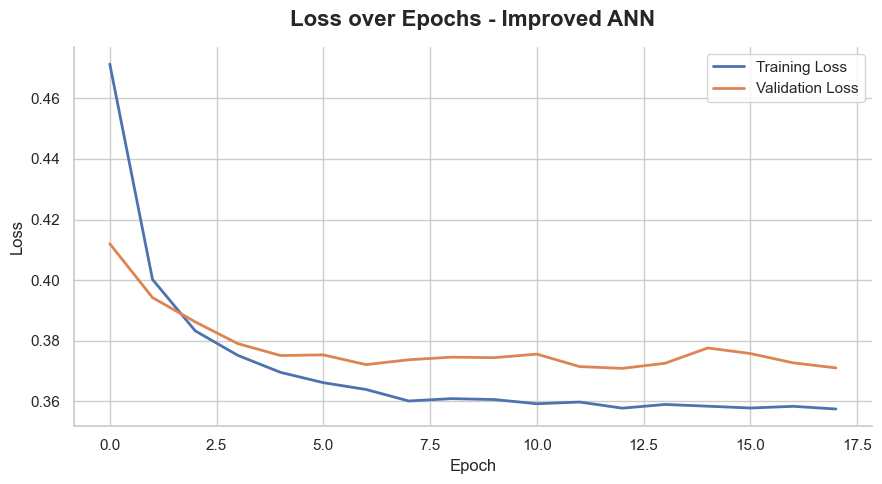

In [28]:
improved_history_df = pd.DataFrame(improved_history.history)

plt.figure(figsize=(9, 5))

plt.plot(improved_history_df["loss"], label="Training Loss", linewidth=2)
plt.plot(improved_history_df["val_loss"], label="Validation Loss", linewidth=2)

plt.title("Loss over Epochs - Improved ANN", weight="bold", pad=15)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

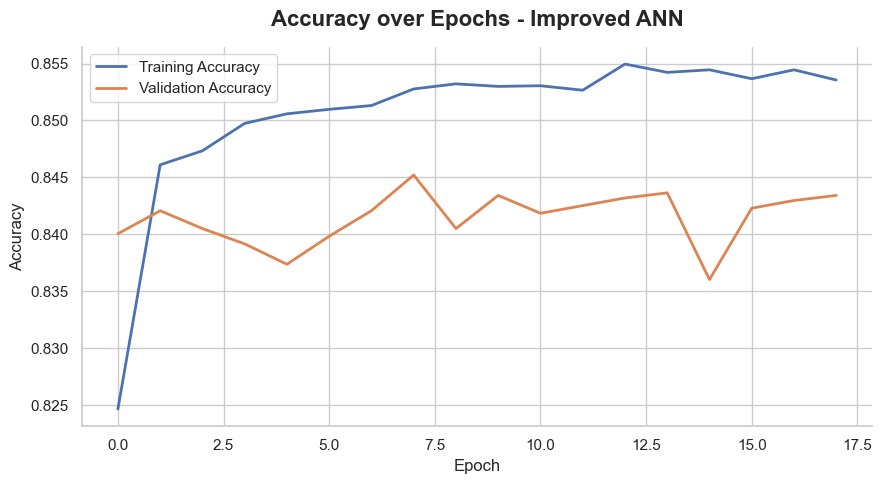

In [29]:
plt.figure(figsize=(9, 5))

plt.plot(improved_history_df["accuracy"], label="Training Accuracy", linewidth=2)
plt.plot(improved_history_df["val_accuracy"], label="Validation Accuracy", linewidth=2)

plt.title("Accuracy over Epochs - Improved ANN", weight="bold", pad=15)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

In [30]:
y_pred_proba_improved = improved_model.predict(X_test_processed).ravel()
y_pred_improved = (y_pred_proba_improved >= 0.5).astype(int)

improved_accuracy = accuracy_score(y_test, y_pred_improved)
improved_precision = precision_score(y_test, y_pred_improved)
improved_recall = recall_score(y_test, y_pred_improved)
improved_f1 = f1_score(y_test, y_pred_improved)
improved_roc_auc = roc_auc_score(y_test, y_pred_proba_improved)
improved_avg_precision = average_precision_score(y_test, y_pred_proba_improved)

improved_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Average Precision"],
    "Simple ANN": [accuracy, precision, recall, f1, roc_auc, avg_precision],
    "Improved ANN": [
        improved_accuracy,
        improved_precision,
        improved_recall,
        improved_f1,
        improved_roc_auc,
        improved_avg_precision
    ]
})

improved_results

175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step


,Metric,Simple ANN,Improved ANN
0,Accuracy,0.829242,0.843397
1,Precision,0.845626,0.843966
2,Recall,0.866585,0.898715
3,F1-score,0.855977,0.870480
4,ROC-AUC,0.904164,0.917115
5,Average Precision,0.922671,0.935147


## Model Comparison: Simple ANN vs Improved ANN

The improved ANN model performs better than the simple ANN model on most evaluation metrics.

The accuracy increases from around 82.9% to 84.3%. The ROC-AUC also improves from around 0.90 to 0.92, which means that the improved model has a stronger ability to separate students with and without depression.

The most important improvement is recall for the depression class. The improved model reaches a recall of around 90%, compared to around 87% for the simple ANN. This means that the improved model identifies more students with depression.

In a mental health context, recall is especially important because false negatives mean that students with depression are predicted as not depressed. Therefore, the improved ANN model is more suitable from a risk-detection perspective.

Precision is almost the same between the two models. The improved model has slightly more false positives, but this may be acceptable in a student wellbeing context because it is often better to flag a possible risk than to miss a student who may need support.

Overall, the improved ANN model is selected as the better model because it has higher recall, higher F1-score, higher ROC-AUC and better generalization.

In [33]:
print(classification_report(y_test, y_pred_improved))

              precision    recall  f1-score   support

           0       0.84      0.77      0.80      2313
           1       0.84      0.90      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.84      5581
weighted avg       0.84      0.84      0.84      5581



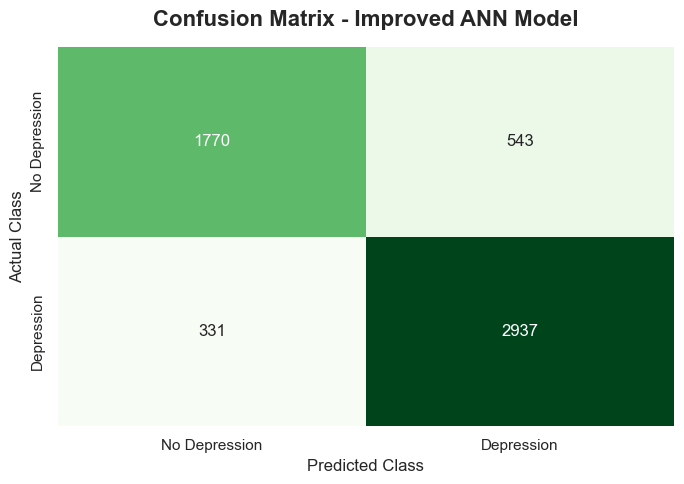

In [32]:
cm_improved = confusion_matrix(y_test, y_pred_improved)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_improved,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=["No Depression", "Depression"],
    yticklabels=["No Depression", "Depression"]
)

plt.title("Confusion Matrix - Improved ANN Model", weight="bold", pad=15)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

## Improved ANN Model Interpretation

The improved ANN model uses Dropout, L2 regularization and EarlyStopping to reduce overfitting.

Compared to the simple ANN model, the improved model has a more stable validation loss. The gap between training and validation performance is smaller, which indicates better generalization.

The confusion matrix shows that the improved model reduces the number of false negatives. This is important in a mental health context because false negatives mean that students with depression are predicted as not depressed.

The improved model has slightly more false positives, meaning that some students without depression are predicted as depressed. However, in a student wellbeing context, this may be more acceptable than missing students who may need support.

Overall, the improved ANN model is better from a risk-detection perspective because it identifies more students in the depression class.

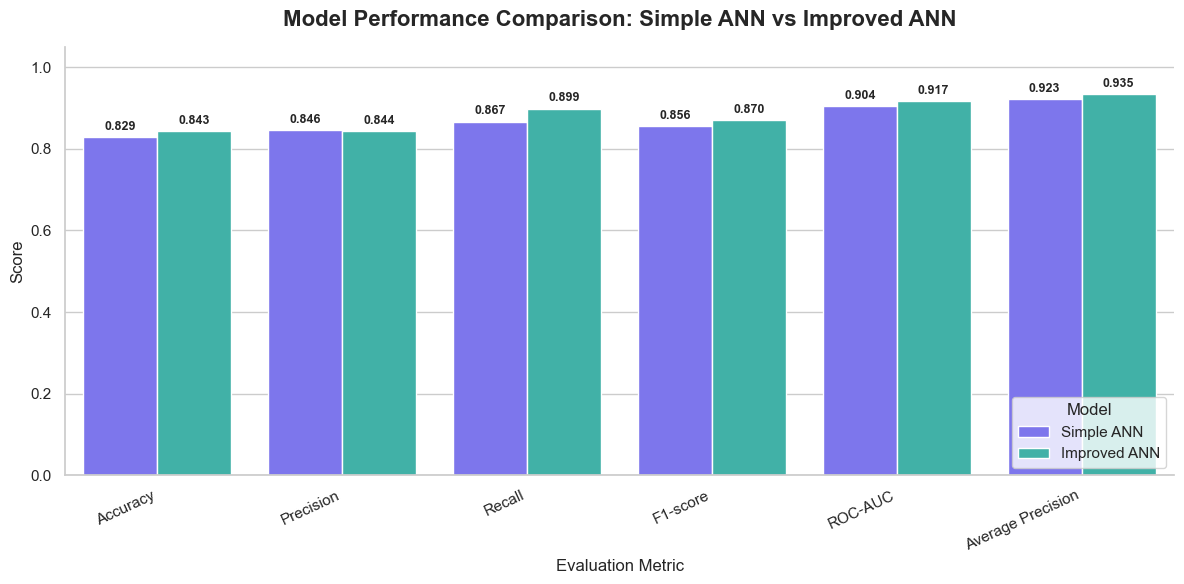

In [35]:
comparison_plot_df = improved_results.melt(
    id_vars="Metric",
    value_vars=["Simple ANN", "Improved ANN"],
    var_name="Model",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=comparison_plot_df,
    x="Metric",
    y="Score",
    hue="Model",
    palette=["#6C63FF", "#2EC4B6"]
)

plt.title("Model Performance Comparison: Simple ANN vs Improved ANN", weight="bold", pad=15)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.xticks(rotation=25, ha="right")
plt.legend(title="Model", loc="lower right")

# Add labels only on real bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9,
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

## Final Comparison

The improved ANN model performs better than the simple ANN model on most metrics.

The most important improvement is recall, which increases from 0.867 to 0.899. This means the improved model identifies more students in the depression class.

The improved model also has higher accuracy, F1-score, ROC-AUC and Average Precision. Therefore, the improved ANN is selected as the better model.

In this project, recall is especially important because the goal is to detect possible risk patterns connected to student depression. However, the model should only be used as a supportive analytical tool and not as a medical diagnosis system.